# Проектая работа - маркетинговый анализ развлекательного приложения Procrastinate Pro+

Цель: разобраться в причинах убытков за последние несколько месяцев, несмотря на огромные вложения в рекламу, и помочь компании выйти в плюс

Есть данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года:
- лог сервера с данными об их посещениях,
- выгрузка их покупок за этот период,
- рекламные расходы

Предстоит изучить:
- откуда приходят пользователи и какими устройствами они пользуются
- сколько стоит привлечение пользователей из различных рекламных каналов
- сколько денег приносит каждый клиент
- когда расходы на привлечение клиента окупаются
- какие факторы мешают привлечению клиентов

***План работ:***

**Шаг 1. Загрузка данных и подготовка их к анализу** \
Загрузить данные и изучить общую информацию о полученном датафреймах \
Выполнить предобработку

**Шаг 2. Задать функции для расчёта и анализа LTV, ROI, удержания и конверсии** \
Это функции для вычисления значений метрик:
- get_profiles() — для создания профилей пользователей,
- get_retention() — для подсчёта Retention Rate,
- get_conversion() — для подсчёта конверсии,
- get_ltv() — для подсчёта LTV

А также функции для построения графиков:
- filter_data() — для сглаживания данных,
- plot_retention() — для построения графика Retention Rate,
- plot_conversion() — для построения графика конверсии,
- plot_ltv_roi — для визуализации LTV и ROI
 
**Шаг 3. Провести исследовательский анализ данных** \
3.1 Составить профили пользователей. Определить минимальную и максимальную даты привлечения пользователей \
3.2 Выяснить, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Построить таблицу, отражающую количество пользователей и долю платящих из каждой страны \
3.3 Узнать, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Построить таблицу, отражающую количество пользователей и долю платящих для каждого устройства \
3.4 Изучить рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Построить таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения

**Шаг 4. Маркетинг** \
4.1 Посчитать общую сумму расходов на маркетинг \
4.2 Выяснить, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник \
4.3 Построить график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализировать динамику изменения расходов во времени по месяцам по каждому источнику \
4.4 Узнать, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Использовать профили пользователей

**Шаг 5. Оценить окупаемость рекламы** \
Используя графики LTV, ROI и CAC, проанализировать окупаемость рекламы. Считая, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определить самостоятельно. 

- Проанализировать окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI 
- Проверить конверсию пользователей и динамику её изменения. То же самое сделать с удержанием пользователей. Пострить и изучить графики конверсии и удержания 
- Проанализировать окупаемость рекламы с разбивкой по устройствам. Построить графики LTV и ROI, а также графики динамики LTV, CAC и ROI 
- Проанализировать окупаемость рекламы с разбивкой по странам. Построить графики LTV и ROI, а также графики динамики LTV, CAC и ROI 
- Проанализировать окупаемость рекламы с разбивкой по рекламным каналам. Построить графики LTV и ROI, а также графики динамики LTV, CAC и ROI 

Ответить на такие вопросы: 
- Окупается ли реклама, направленная на привлечение пользователей в целом?
- Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
- Чем могут быть вызваны проблемы окупаемости?

Написать вывод, описать возможные причины обнаруженных проблем и промежуточные рекомендации для рекламного отдела. 

**Шаг 6. Написать общий вывод** 
- Выделить причины неэффективности привлечения пользователей
- Сформулировать рекомендации для отдела маркетинга

## Загрузите данные и подготовьте их к анализу

Загрузите данные о визитах, заказах и рекламных расходах из CSV-файлов в переменные.

**Пути к файлам**

- визиты: `/datasets/visits_info_short.csv`;
- заказы: `/datasets/orders_info_short.csv`;
- расходы: `/datasets/costs_info_short.csv`.

Изучите данные и выполните предобработку. Есть ли в данных пропуски и дубликаты? Убедитесь, что типы данных во всех колонках соответствуют сохранённым в них значениям. Обратите внимание на столбцы с датой и временем.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from matplotlib import pyplot as plt

In [2]:
visits=pd.read_csv('/datasets/visits_info_short.csv', parse_dates=['Session Start', 'Session End'])# прочла csv-файл c информацией о посещениях сайта
visits.info()
display(visits.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   User Id        309901 non-null  int64         
 1   Region         309901 non-null  object        
 2   Device         309901 non-null  object        
 3   Channel        309901 non-null  object        
 4   Session Start  309901 non-null  datetime64[ns]
 5   Session End    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40
5,90242400005,United States,iPhone,RocketSuperAds,2019-05-01 07:14:52,2019-05-01 08:19:56
6,43958116050,United States,Android,organic,2019-05-01 09:03:21,2019-05-01 10:08:39
7,185365244969,United States,iPhone,organic,2019-05-01 09:37:03,2019-05-01 10:00:43
8,446013509831,United States,iPhone,RocketSuperAds,2019-05-01 10:26:00,2019-05-01 10:59:17
9,100970711362,United States,Mac,TipTop,2019-05-01 04:39:53,2019-05-01 04:57:05


In [3]:
display(visits.isna().sum()) # количество пропущенных значений для каждого столбца 
visits.duplicated().sum() # число дубликатов 

User Id          0
Region           0
Device           0
Channel          0
Session Start    0
Session End      0
dtype: int64

0

In [4]:
orders=pd.read_csv('/datasets/orders_info_short.csv', parse_dates=['Event Dt'])# прочла csv-файл c информацией о заказах
orders.info()
display(orders.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   User Id   40212 non-null  int64         
 1   Event Dt  40212 non-null  datetime64[ns]
 2   Revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99
5,129100331057,2019-05-01 01:56:28,4.99
6,626807144131,2019-05-01 02:39:21,4.99
7,914062168985,2019-05-01 02:02:18,4.99
8,769669137453,2019-05-01 03:39:47,4.99
9,434198630691,2019-05-01 18:16:50,5.99


In [5]:
display(orders.isna().sum()) # количество пропущенных значений для каждого столбца 
orders.duplicated().sum() # число дубликатов 

User Id     0
Event Dt    0
Revenue     0
dtype: int64

0

In [6]:
costs=pd.read_csv('/datasets/costs_info_short.csv', parse_dates=['dt'])# прочла csv-файл c информацией о расходах на рекламу
costs.info()
display(costs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       1800 non-null   datetime64[ns]
 1   Channel  1800 non-null   object        
 2   costs    1800 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 42.3+ KB


,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1
5,2019-05-06,FaceBoom,118.8
6,2019-05-07,FaceBoom,101.2
7,2019-05-08,FaceBoom,100.1
8,2019-05-09,FaceBoom,93.5
9,2019-05-10,FaceBoom,104.5


In [7]:
display(costs.isna().sum()) # количество пропущенных значений для каждого столбца 
costs.duplicated().sum() # число дубликатов 

dt         0
Channel    0
costs      0
dtype: int64

0

Пропуски и дубликаты отстусвуют. Столбцы с датой и временем в каждом датасете необходимо перевести в формат datetime. Преобразовать названия столбцов. 

In [8]:
# преобразование имен всех столбцов к нижему регистру
visits.rename(columns=str.lower, inplace=True)
visits.columns=visits.columns.str.replace(' ', '_')
print(list(visits.columns.values))

orders.rename(columns=str.lower, inplace=True)
orders.columns=orders.columns.str.replace(' ', '_')
print(list(orders.columns.values))

costs.rename(columns=str.lower, inplace=True)
costs.columns=costs.columns.str.replace(' ', '_')
list(costs.columns.values)

['user_id', 'region', 'device', 'channel', 'session_start', 'session_end']
['user_id', 'event_dt', 'revenue']


['dt', 'channel', 'costs']

In [9]:
# добавление отдельных столбов 
costs['dt']=costs['dt'].dt.date
visits['session_yaer']=visits['session_start'].dt.year
visits['session_month']=visits['session_start'].dt.month
visits['session_week']=visits['session_start'].dt.isocalendar().week
visits['session_date']=visits['session_start'].dt.date
visits.head(5)

,user_id,region,device,channel,session_start,session_end,session_yaer,session_month,session_week,session_date
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01,2019,5,18,2019-05-01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35,2019,5,18,2019-05-01
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08,2019,5,18,2019-05-01
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25,2019,5,18,2019-05-01
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40,2019,5,18,2019-05-01


In [10]:
# уникальные значения в столбцах 
print(visits['region'].unique())
print(visits['device'].unique())
print(visits['channel'].unique())
print(costs['channel'].unique())

['United States' 'UK' 'France' 'Germany']
['iPhone' 'Mac' 'Android' 'PC']
['organic' 'TipTop' 'RocketSuperAds' 'YRabbit' 'FaceBoom' 'MediaTornado'
 'AdNonSense' 'LeapBob' 'WahooNetBanner' 'OppleCreativeMedia'
 'lambdaMediaAds']
['FaceBoom' 'MediaTornado' 'RocketSuperAds' 'TipTop' 'YRabbit'
 'AdNonSense' 'LeapBob' 'OppleCreativeMedia' 'WahooNetBanner'
 'lambdaMediaAds']


***Вывод:***
Пропуски и дубликаты отстусвуют. Столбцы с датой и временем в каждом датасете переведены в формат datetime. Корректно переобразовали названия столбов. В исследовании данные о 4 странах: США, Великобритания, Франция и Германия. А так же данные о следующих устройствах: iPhone, Android, PC, Mac.

## Задайте функции для расчёта и анализа LTV, ROI, удержания и конверсии.

Разрешается использовать функции, с которыми вы познакомились в теоретических уроках.

Это функции для вычисления значений метрик:

- `get_profiles()` — для создания профилей пользователей,
- `get_retention()` — для подсчёта Retention Rate,
- `get_conversion()` — для подсчёта конверсии,
- `get_ltv()` — для подсчёта LTV.

А также функции для построения графиков:

- `filter_data()` — для сглаживания данных,
- `plot_retention()` — для построения графика Retention Rate,
- `plot_conversion()` — для построения графика конверсии,
- `plot_ltv_roi` — для визуализации LTV и ROI.

In [11]:
# функция создания профилей
def get_profiles(visits, orders, ad_costs):
    # находим параметры первых посещений
    profiles = (
        visits.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['first_ts'] = pd.to_datetime(profiles['first_ts'])
    profiles['dt'] = profiles['first_ts'].dt.date  
    profiles['month'] = profiles['first_ts'].dt.month  

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

In [12]:
# функция для расчёта удержания
def get_retention(
    profiles,
    visits_info_short,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        visits_info_short[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [13]:
# функция для расчёта конверсии
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [14]:
# функция для расчёта LTV и ROI
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

In [15]:
# функция для сглаживания фрейма
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df

In [16]:
# функция для визуализации удержания
def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
# функция для визуализации конверсии
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

In [18]:
# функция для визуализации LTV и ROI
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

***Вывод:***
Написали функции для создания профилей, расчёта удержания, конверсии, LTV и ROI: get_profiles(), get_retention(), get_conversion() и get_ltv(). А также функции для построения графиков: filter_data() — для сглаживания данных, plot_retention() — для построения графика коэффициента удержания, plot_conversion() — для построения графика конверсии, plot_ltv_roi — для визуализации LTV и ROI.

## Исследовательский анализ данных

### Составить профили пользователей. Определить минимальную и максимальную даты привлечения пользователей

In [19]:
# получаем профили пользователей
profiles = get_profiles(visits, orders, costs)
display(profiles.head()) 

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,5,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,7,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,10,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,8,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,10,False,0.230769


In [20]:
# момент анализа
observation_date = datetime(2019, 11, 1).date()
observation_date

datetime.date(2019, 11, 1)

In [21]:
# горизонт анализа
horizon_days = 14

In [22]:
# создание опции «игнорировать горизонт»
ignore_horizon = False

In [23]:
# минимальная дата привлечения пользователей
costs['dt'].min()

datetime.date(2019, 5, 1)

In [24]:
# максимально возможная дата привлечения с учётом горизонта
observation_date - timedelta(days=horizon_days - 1)

datetime.date(2019, 10, 19)

***Итог:***
Задали момент - 1 ноября 2019 года и горизонт анализа - 14 дней. Следовательно, максимально возможная дата привлечения с учётом горизонта это 19 октября 2019 года. Минимальная дата привлечения пользователей - это первая дата посещения - 1 мая 2019 года.

### Выяснить, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Построить таблицу, отражающую количество пользователей и долю платящих из каждой страны 

In [25]:
# группировка по странам и подсчет платящих пользователей 
region_payer=profiles.groupby('region').agg({'user_id': 'nunique', 'payer': 'sum'})
region_payer['rate_payer']=region_payer['payer']/region_payer['user_id']
region_payer.sort_values('payer', ascending=False).round(2)

,user_id,payer,rate_payer
region,,,
United States,100002,6902,0.07
UK,17575,700,0.04
France,17450,663,0.04
Germany,14981,616,0.04


***Итог:***
В США самое большое количество пользователей и самое большое количество платящих пользователей, но доля от общего кол-ва пользователей всего 7%. Следовательно, в основной массе пользователи неплатящие - 93%, а в Великобритании, во Франции и в Германии - по 96% неплатящих пользователей. 

### Узнать, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Построить таблицу, отражающую количество пользователей и долю платящих для каждого устройства 

In [26]:
# группировка по типу устройств и подсчет платящих пользователей 
device_payer=profiles.groupby('device').agg({'user_id': 'nunique', 'payer': 'sum'})
device_payer['rate_payer']=device_payer['payer']/device_payer['user_id']
device_payer.sort_values('payer', ascending=False).round(2)

,user_id,payer,rate_payer
device,,,
iPhone,54479,3382,0.06
Android,35032,2050,0.06
Mac,30042,1912,0.06
PC,30455,1537,0.05


***Итог:***
Самое большое количество пользователей и самое большое количество платящих пользователей с типом устройства iPhone, но доля от общего кол-ва пользователей всего 6%. Пользователей с типом устройства Mac почти в 2 раза меньше, чем с iPhone, но доля платящих та же - 6%. Неплатящих пользователей по 94-95%.

### Изучить рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Построить таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения

In [27]:
# группировка каналу и подсчет платящих пользователей 
channel_payer=profiles.groupby('channel').agg({'user_id': 'nunique', 'payer': 'sum'})
channel_payer['rate_payer']=channel_payer['payer']/channel_payer['user_id']
channel_payer.sort_values('payer', ascending=False).round(2)

,user_id,payer,rate_payer
channel,,,
FaceBoom,29144,3557,0.12
TipTop,19561,1878,0.10
organic,56439,1160,0.02
WahooNetBanner,8553,453,0.05
AdNonSense,3880,440,0.11
RocketSuperAds,4448,352,0.08
LeapBob,8553,262,0.03
OppleCreativeMedia,8605,233,0.03
lambdaMediaAds,2149,225,0.10


***Итог:***
Самое большое количество платящих пользователей через канал FaceBoom, доля платящих 12%. Но самое большое количество пользователей через канал organic, имеющий самую низкую долю платящих пользователей - 2%.Еще относительно высокие показатели имеет канал TipTop. Каналы lambdaMediaAds и AdNonSense имеет хороший оборот - меньше пользователей, но доля платящих высока.

***Вывод:***

Установлен момент анализа, как указано в условии проекта - 1 ноября 2019 года. Горизонт анализа установлен в 14 дней.  Следовательно, максимально возможная дата привлечения с учётом горизонта это 19 октября 2019 года. Минимальная дата привлечения пользователей - это первая дата посещения - 1 мая 2019 года. \
Как было выявленно ранее, в исследовании предоставлены данные о 4 странах: США, Великобритания, Франция и Германия. В США самое большое количество пользователей и самое большое количество платящих пользователей. Доля платящих пользователй в целом примерно 5%. Довольно мало. \
Клиенты пользуются следущими устройствами: iPhone, Android, Mac и PC. Самый востребованный типом относительно других типов устройств и относительно платящих пользователей - iPhone. Доли платящих пользователей практически одинаковый для всех типов - 6%, у PC - 5%. Но пользователей с типом устройства Mac почти в 2 раза меньше, чем с iPhone, но доля платящих та же - 6%. Возможно с Mac устройства удобнее заходить в приложение и оплачивать.\
В исследовании предоставлены данные о 10 рекламных источников и органический канал(самостоятельный переход на страницу). Самое большое количество платящих пользователей через канал FaceBoom, имеющий самую высокую доля платящих 12%. Но самое большое количество пользователей через канал organic, имеющий самую низкую долю платящих пользователей - 2%. Еще относительно высокие показатели имеет канал TipTop. Каналы lambdaMediaAds и AdNonSense имеет хороший оборот - меньше пользователей, но доля платящих высока. 

## Маркетинг

### Посчитать общую сумму расходов на маркетинг

In [28]:
print('Общую сумму расходов на маркетинг:', costs['costs'].sum().round(2),'руб.')

Общую сумму расходов на маркетинг: 105497.3 руб.


In [29]:
rete_costs=costs['costs'].sum()/orders['revenue'].sum()
print('Доля расходов от суммы заказов составляет {:.2%}'.format(rete_costs))

Доля расходов от суммы заказов составляет 48.85%


***Итог:***
Общую сумму расходов на маркетинг: 105497.3 руб - это 48.85% от суммы заказов. 

### Выяснить, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник

In [30]:
# распределение трат по рекламным источникам
channel_costs=costs.groupby('channel').agg({'costs': 'sum'}).sort_values(by='costs', ascending=False)
channel_costs

,costs
channel,
TipTop,54751.30
FaceBoom,32445.60
WahooNetBanner,5151.00
AdNonSense,3911.25
OppleCreativeMedia,2151.25
RocketSuperAds,1833.00
LeapBob,1797.60
lambdaMediaAds,1557.60
MediaTornado,954.48


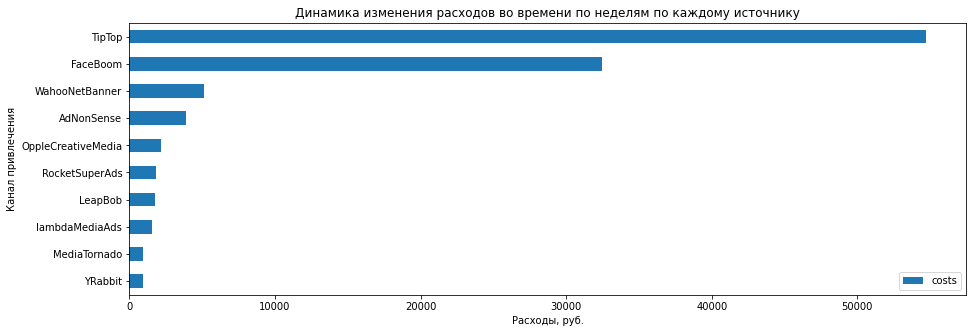

In [31]:
channel_costs.sort_values(by='costs').plot(kind = 'barh', figsize = (15,5), fontsize = 10)
plt.title('Динамика изменения расходов во времени по неделям по каждому источнику')
plt.xlabel('Расходы, руб.')
plt.ylabel('Канал привлечения')
plt.legend()
plt.show()

***Итог:***
Выделяются 2 канала с крайне высокими тратами на маркетинг- TipTop и FaceBoom.

### Построить график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализировать динамику изменения расходов во времени по месяцам по каждому источнику

In [32]:
costs['dt']=pd.to_datetime(costs['dt'])
costs['costs_month']=costs['dt'].dt.month
costs['costs_week']=costs['dt'].dt.isocalendar().week

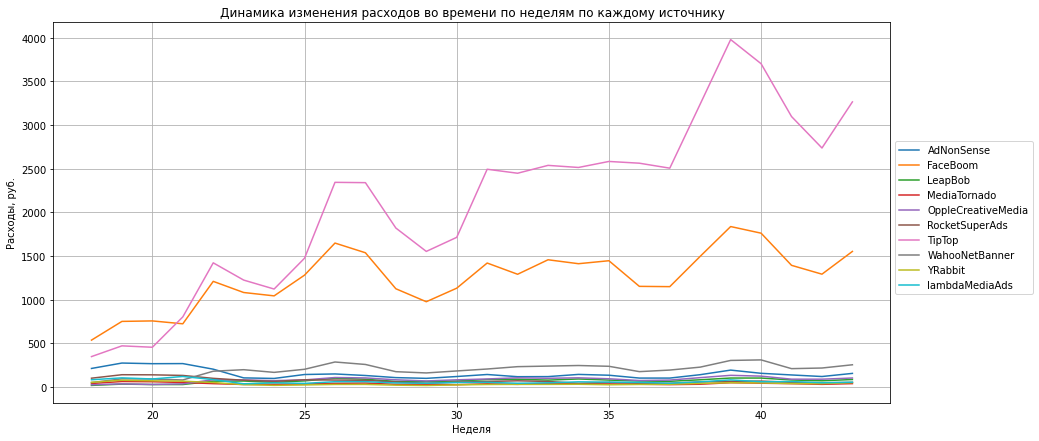

In [33]:
costs.pivot_table(index='costs_week', columns='channel', values='costs', aggfunc='sum').plot(figsize=(15, 7), grid=True)
plt.title('Динамика изменения расходов во времени по неделям по каждому источнику')
plt.xlabel('Неделя')
plt.ylabel('Расходы, руб.')
plt.legend(bbox_to_anchor=(1, 0.7))
plt.show()

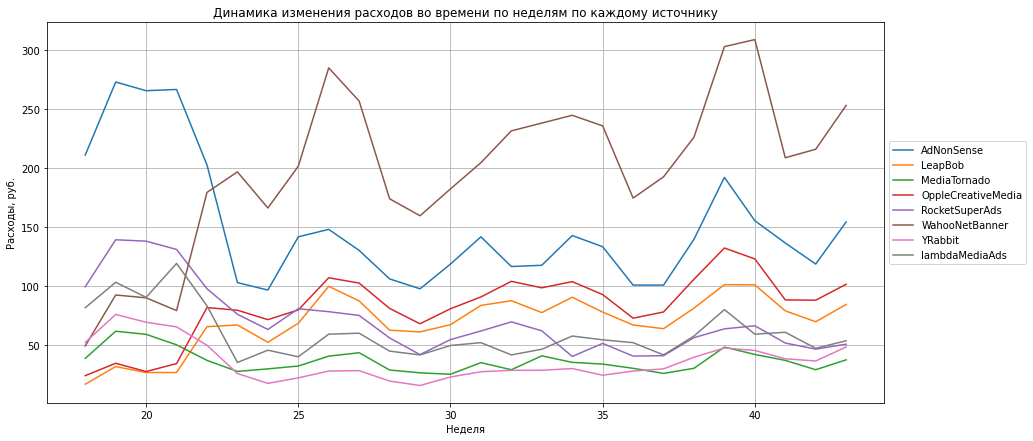

In [34]:
# без учета двух каналов "TipTop" и "FaceBoom"
slice_costs=costs.query('channel != "TipTop" and channel != "FaceBoom"')
slice_costs.pivot_table(index='costs_week', columns='channel', values='costs', aggfunc='sum').plot(figsize=(15, 7), grid=True)
plt.title('Динамика изменения расходов во времени по неделям по каждому источнику')
plt.xlabel('Неделя')
plt.ylabel('Расходы, руб.')
plt.legend(bbox_to_anchor=(1, 0.7))
plt.show()

Расходы в неделю не превышают 320 руб. 

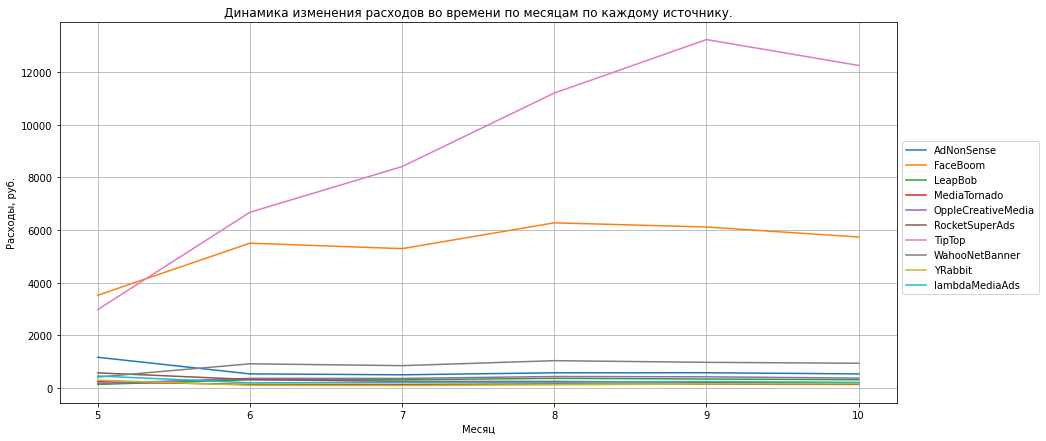

In [35]:
costs.pivot_table(index='costs_month', columns='channel', values='costs', aggfunc='sum').plot(figsize=(15, 7), grid=True)
plt.title('Динамика изменения расходов во времени по месяцам по каждому источнику.')
plt.xlabel('Месяц')
plt.ylabel('Расходы, руб.')
plt.legend(bbox_to_anchor=(1, 0.7))
plt.show()

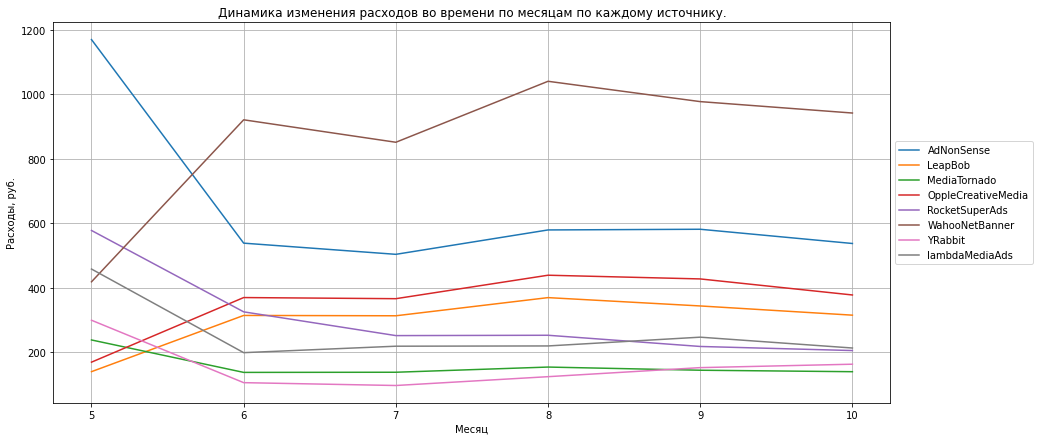

In [36]:
# без учета двух каналов "TipTop" и "FaceBoom"
slice_costs.pivot_table(index='costs_month', columns='channel', values='costs', aggfunc='sum').plot(figsize=(15, 7), grid=True)
plt.title('Динамика изменения расходов во времени по месяцам по каждому источнику.')
plt.xlabel('Месяц')
plt.ylabel('Расходы, руб.')
plt.legend(bbox_to_anchor=(1, 0.7))
plt.show()

***Итог:*** \
Расходы в неделю не превышают 320 руб, в месяц не превышают 13000 руб. \
Растущие по расходам калалы: WahooNetBanner, OppleCreativeMedia, LeapBob и два канала с крайне высокорастущими расходами - TipTop и FaceBoom.  \
Сократили свои расходы следущие каналы привлечения: AdNonSense, RocketSuperAds, lambdaMediaAds, YRabbit и MediaTornado.

### Узнать, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Использовать профили пользователей

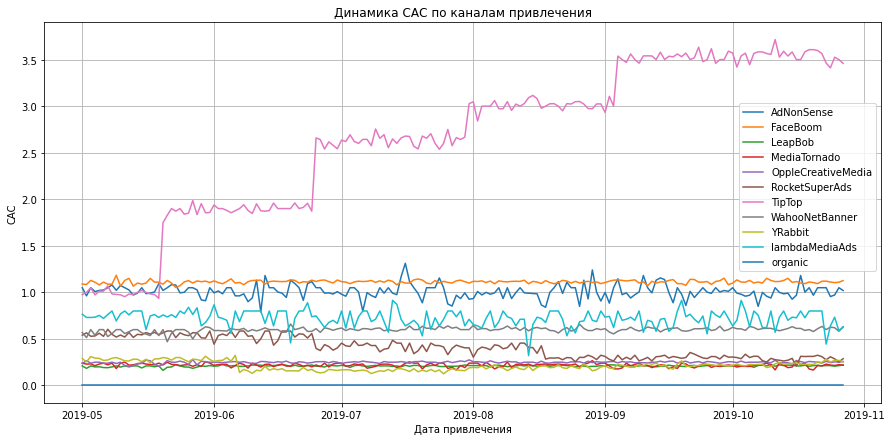

In [37]:
profiles.pivot_table(index='dt', columns='channel', values='acquisition_cost', aggfunc='mean').plot(figsize=(15, 7), grid=True)
plt.ylabel('CAC')
plt.xlabel('Дата привлечения')
plt.title('Динамика САС по каналам привлечения')
plt.legend(bbox_to_anchor=(1, 0.8))
plt.show()

***Итог:***
Средняя стоимость привелечения одного пользователя по всем каналам стабильна и не превышает 1.5, кроме канала TipTop. По данному каналу наблюдается рост в 3.5 раза. 
Стоимость привелечения по каналу organic равна 0, так как клиенты переходя в приложение самостоятельно(без рекламы).

***Вывод:*** \
Общую сумму расходов на маркетинг: 105497.3 руб - это 48.85% от суммы заказов. Довольно много. \
Выделяются 2 канала с крайне высокими тратами на маркетинг- TipTop и FaceBoom - свыше 30000 руб. В то время, как на остальные каналы расходы менее, чем по 6000 руб. \
Растущие по расходам калалы: WahooNetBanner, OppleCreativeMedia, LeapBob и два канала с крайне высокорастущими расходами - TipTop и FaceBoom. Самые высокие раходы по этим 5 каналам в июне и август-сенятбрь.
Сократили свои расходы следущие каналы привлечения: AdNonSense, RocketSuperAds, lambdaMediaAds, YRabbit и MediaTornado. Самые низкие раходы по данным каналам в июне и октябре. \
Средняя стоимость привелечения одного пользователя по всем каналам стабильна и не превышает 1.5, кроме канала TipTop. По данному каналу наблюдается рост в 3.5 раза. Стоимость привелечения по каналу organic равна 0, так как клиенты переходя в приложение самостоятельно(без рекламы). 

У каналов AdNonSense, RocketSuperAds, lambdaMediaAds кол-во клиетнов не более 4500, но доля платящих для них высока.
По каналам TipTop и FaceBoom большие расходы на рекламу, что скорее всего и приводило к большому кол-во пользователей и первичным покупкам, но клиенты скорее всего разовые.

## Оцените окупаемость рекламы

Используя графики LTV, ROI и CAC, проанализируйте окупаемость рекламы. Считайте, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определите самостоятельно.

- Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей. Постройте и изучите графики конверсии и удержания.
- Проанализируйте окупаемость рекламы с разбивкой по устройствам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по странам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по рекламным каналам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Ответьте на такие вопросы:
    - Окупается ли реклама, направленная на привлечение пользователей в целом?
    - Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
    - Чем могут быть вызваны проблемы окупаемости?

Напишите вывод, опишите возможные причины обнаруженных проблем и промежуточные рекомендации для рекламного отдела.

In [38]:
# без учета органического трафика
profiles_new = profiles.query('channel != "organic"')

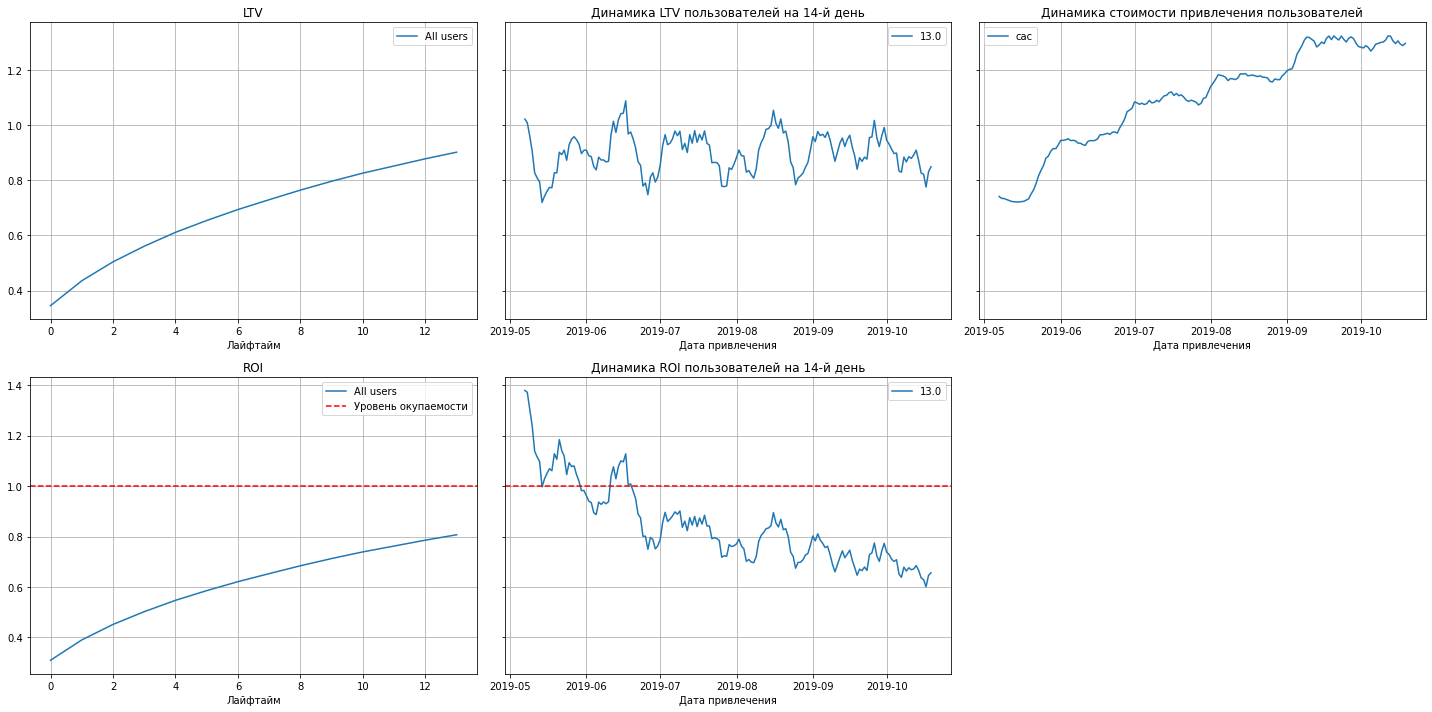

In [39]:
# окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_new, orders, observation_date, horizon_days)
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

По графикам можно сделать такие выводы:
- Реклама не окупается. ROI — около 80%.
- CAC не стабилен - сильно вырос, большой скачек в июне. Значит, дело в увеличении рекламного бюджета. Из-за этого окупаемость сильно упала.
- LTV стабильно растет.

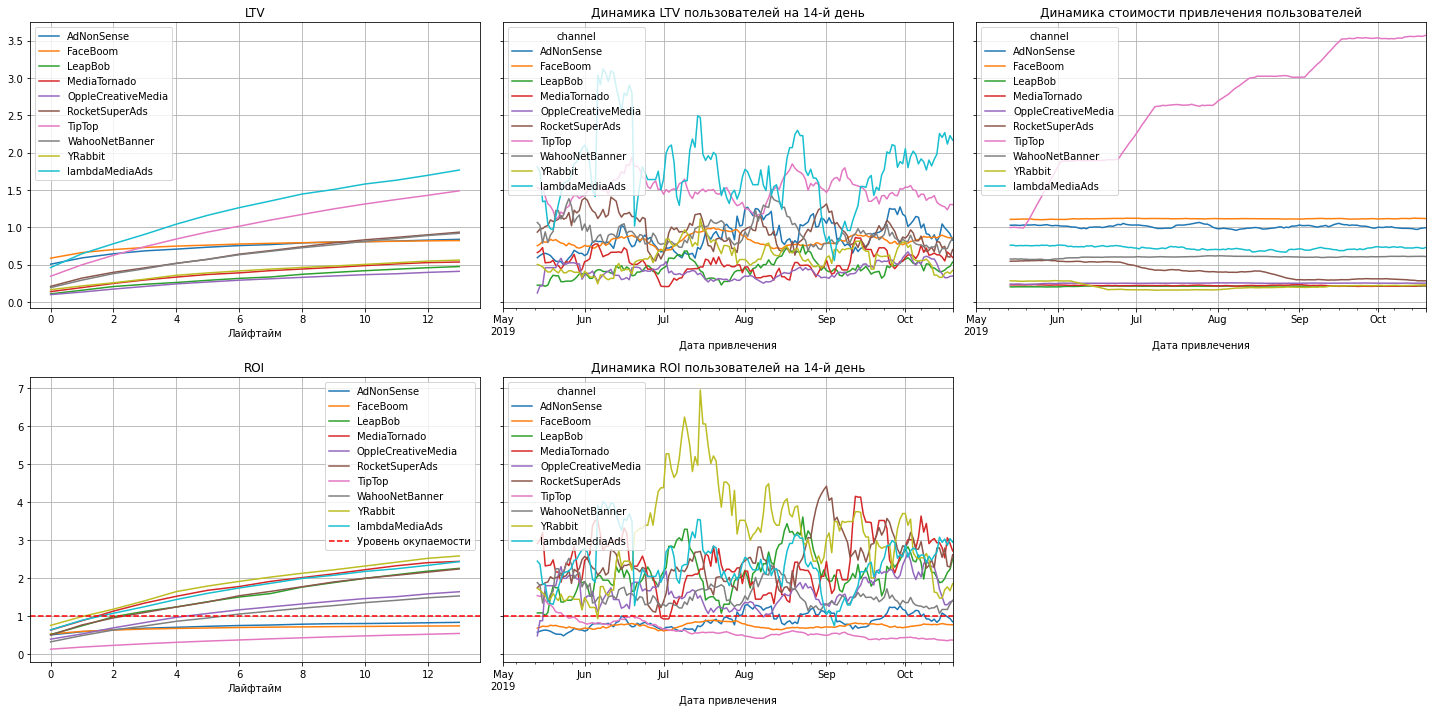

In [40]:
# окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI по каналам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_new, orders, observation_date, horizon_days, dimensions = ['channel'])
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14) 

Не окупается реклама по каналам TipTop, FaceBoom и AdNonSense. Остальные окупаются от 1 до 6 дней.
Нестабильность CAC обусловлена каналом TipTop, у которого крайне высокие затраты на рекламу.
LTV подвержен сезонности, но стабилен.

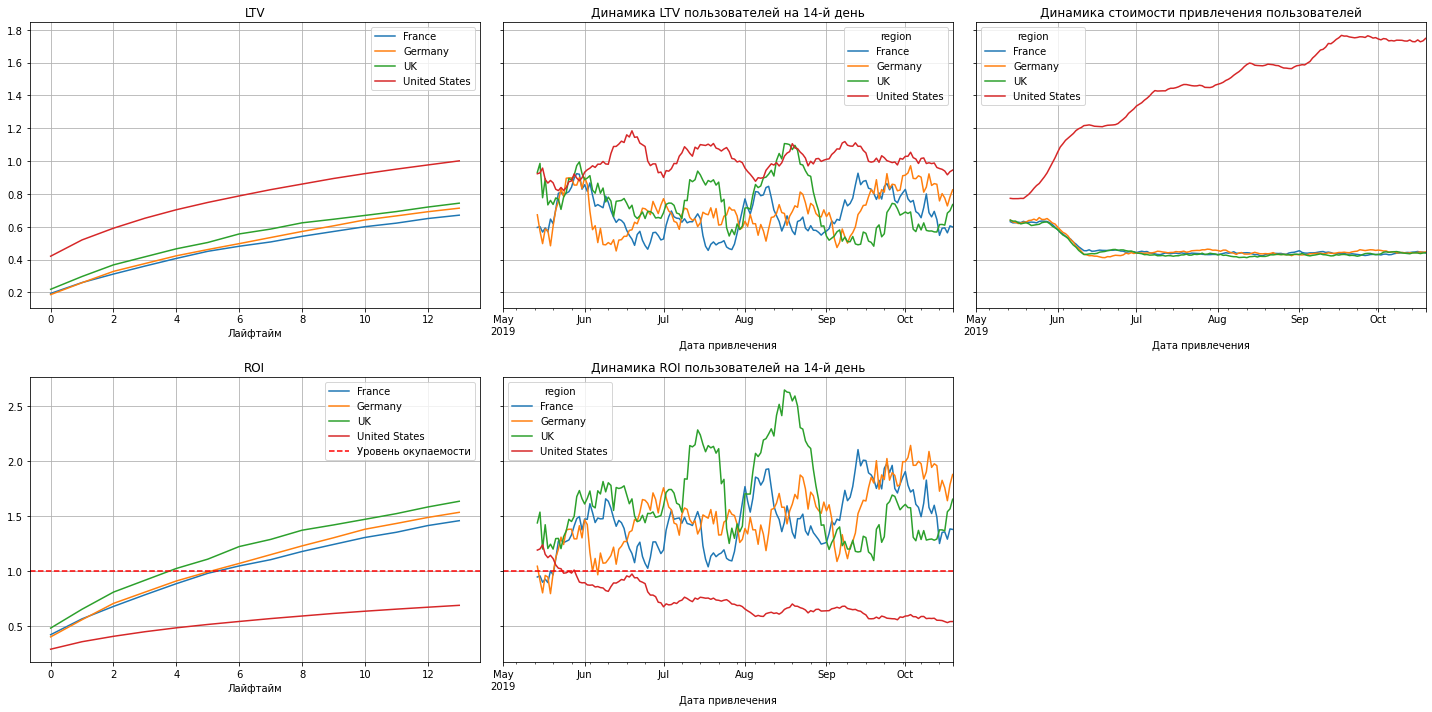

In [41]:
# окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI по странам
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_new, orders, observation_date, horizon_days, dimensions = ['region'])
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14) 

Реклама окупается по всем странам кроме США. Стоимость привлечения пользователей в США во много раз выше, чем в других странах( их САС даже уменьшился). Динамика ROI показывает снижение окупаемости США ниже уровня безубыточности. LTV вырос, возможно клиенты много покупали и быстро ушли. Пользователи из Франции приносят магазину меньше всего выручки.

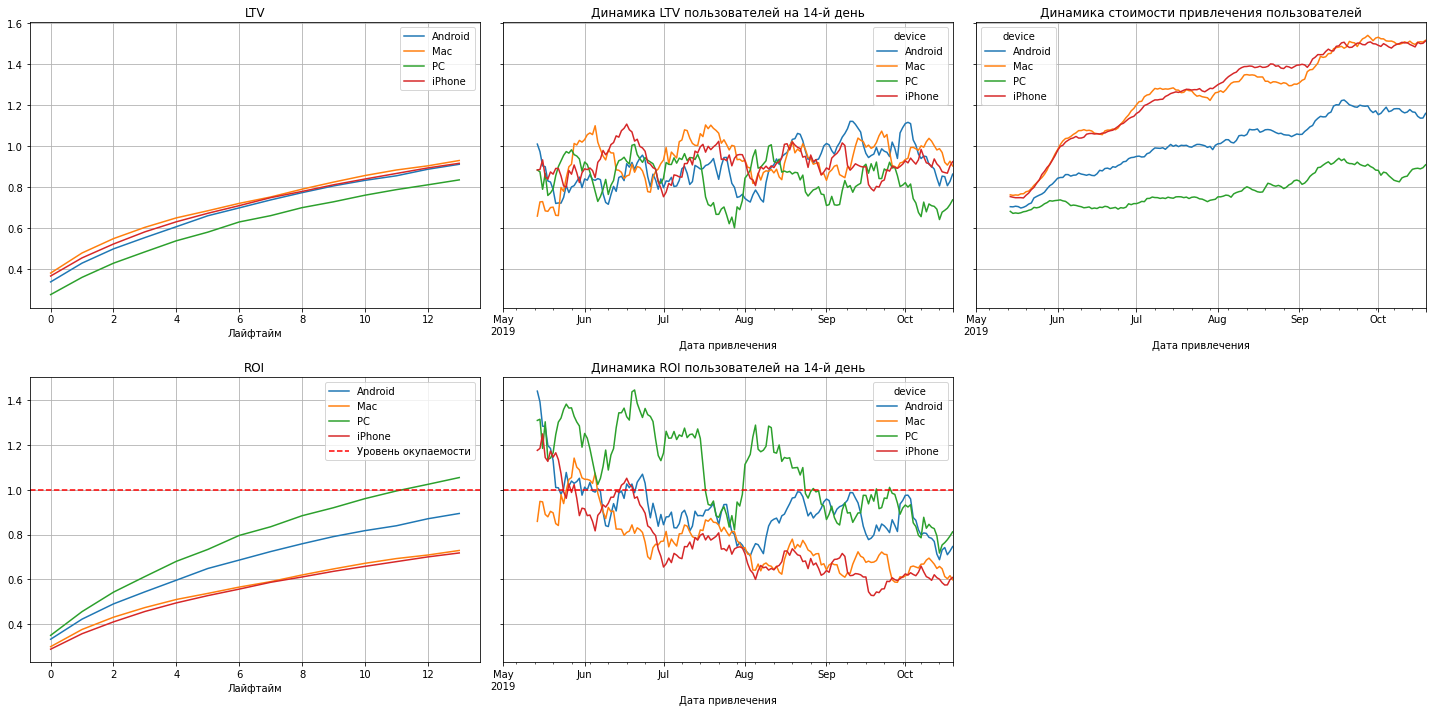

In [42]:
# окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI по типу устройства
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_new, orders, observation_date, horizon_days, dimensions = ['device'])
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14) 

Окупилась реклама у PC спусты 11 дней, у него же и самые малые затраты на привлечение пользователей.
Но стоит отметить, что стоимость привлечения пользователей по всем устройствам увеличивалась, а окупаемость снимжалась. Стабильные качество клиентов. Пользователи PC приносят магазину меньше всего выручки.

Итак, как было установлено ранее, что больше всего платящих пользователей в США с типом устройства iPhone и Mac по каналам TipTop, FaceBoom и AdNonSense. Как оказалась, по данным параметрам реклама не окупилась. Плюс не окупилась реклама с типом устройства Android. Следовательно, можно сделать предположение, что после рекламы клиенты активно закупались, но быстро уходили. Посчитаем и визуализируем конверсию и удержание. 

In [43]:
# функция для визуализации удержания для платящих пользователей
import seaborn as sns
def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке — динамика удержания платящих
    ax2 = plt.subplot(2, 2, 2)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )
    ax3 = plt.subplot(2, 2, 3)
    filtered = retention.query('payer == True').droplevel('payer')
    sns.heatmap(filtered, annot=True, fmt='.0%', ax=ax3)
    plt.title('Тепловая карта удержания платящих пользователей')

    plt.legend()
    plt.tight_layout()
    plt.show()

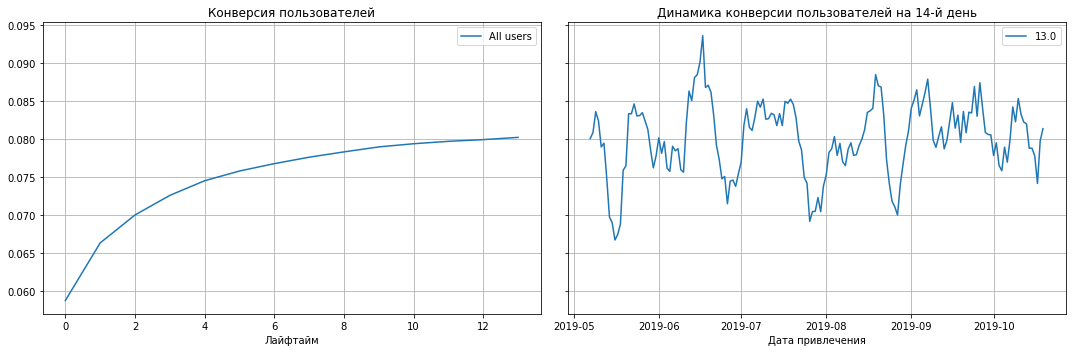

In [44]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_new, orders, observation_date, horizon_days
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)  

No handles with labels found to put in legend.


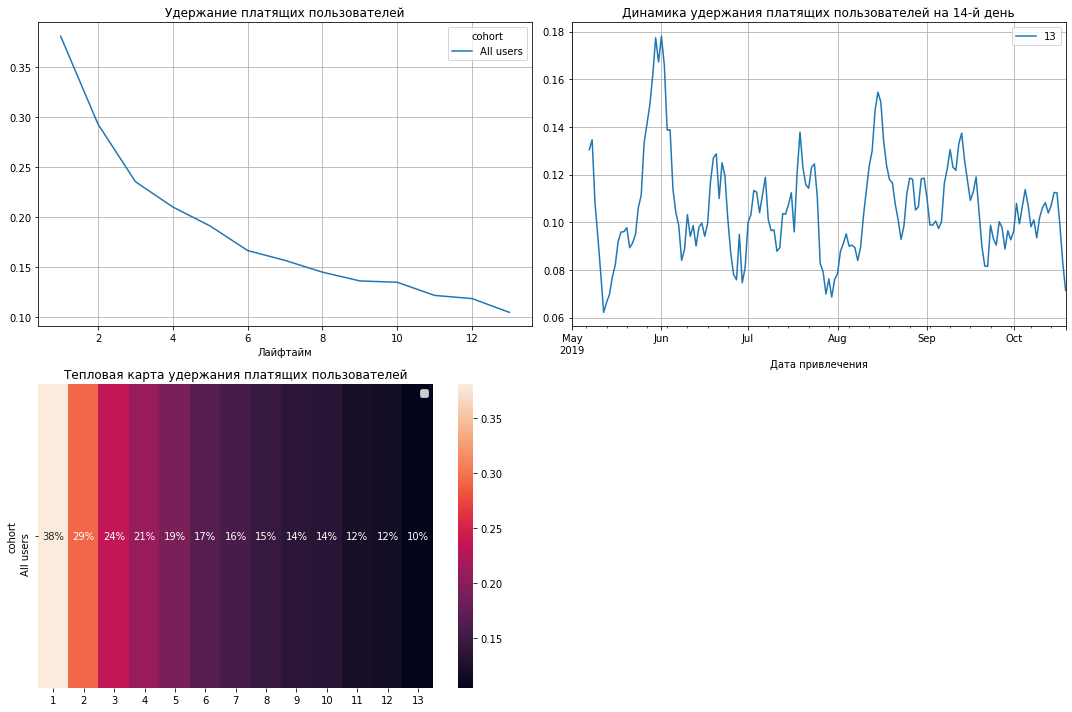

In [45]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_new, visits, observation_date, horizon_days
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Крайне низкий показатель конверсии наблюдается в мае, самый высокий показатель - в июне. Конверсия растет, но до 100% далеко, а удержание падает до 10%, что доказывает предположение - после рекламы клиенты активно закупались, но быстро уходили.

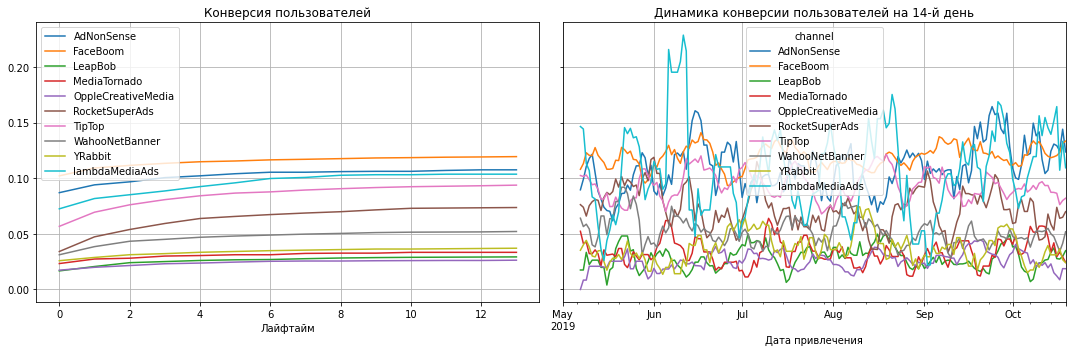

In [46]:
# конверсия пользователей по каналам
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_new, orders, observation_date, horizon_days, dimensions=['channel']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)  

No handles with labels found to put in legend.


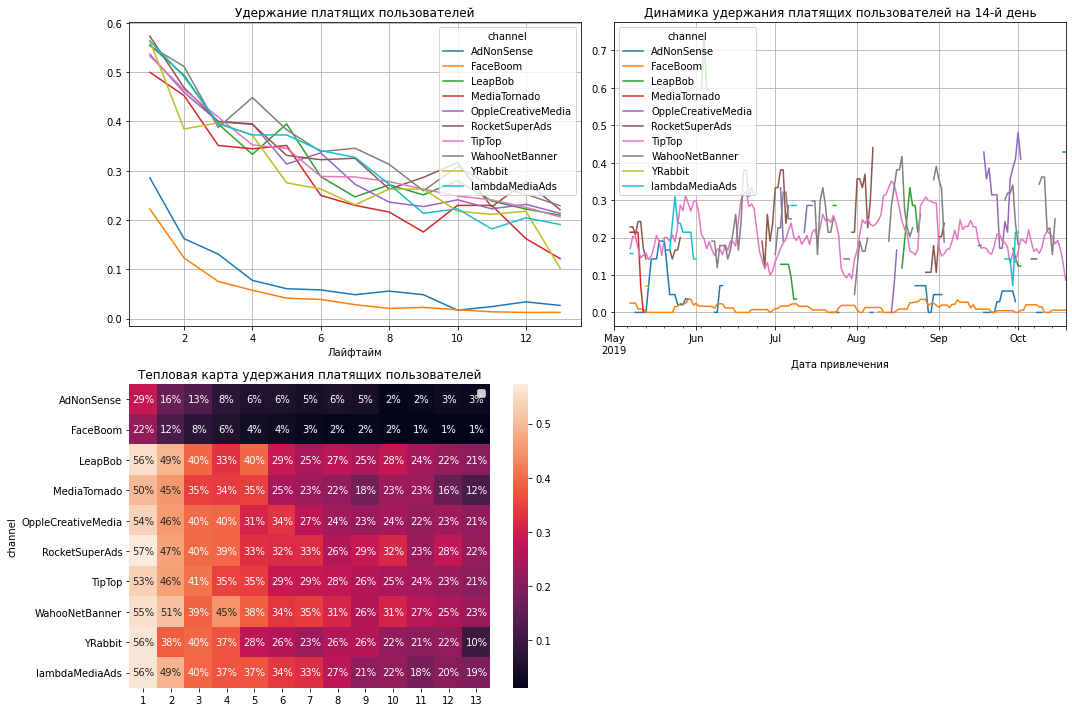

In [47]:
# удержание платящих пользователей по каналам
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_new, visits, observation_date, horizon_days, dimensions=['channel']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

По всем каналам показатель удержания снижался. У каналов FaceBoom (1%) и AdNonSense (3%) самый низкий показатель удержания, но так же вырос показатель конверсии, однако крайне мал.

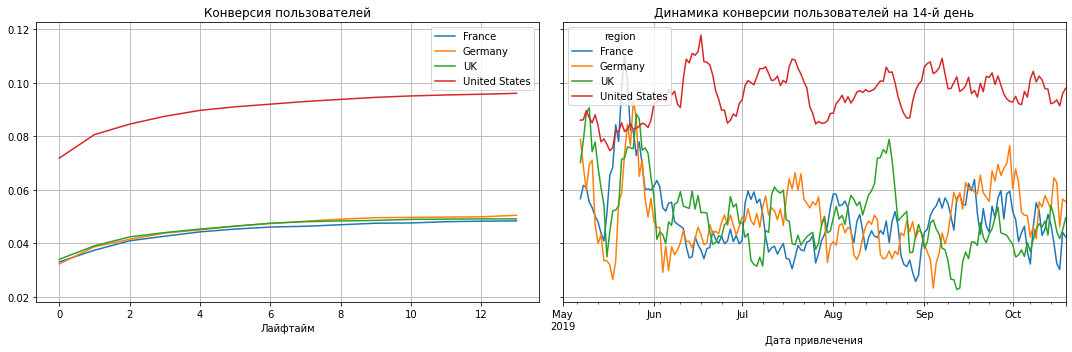

In [48]:
# конверсия пользователей по каналам
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_new, orders, observation_date, horizon_days, dimensions=['region']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

No handles with labels found to put in legend.


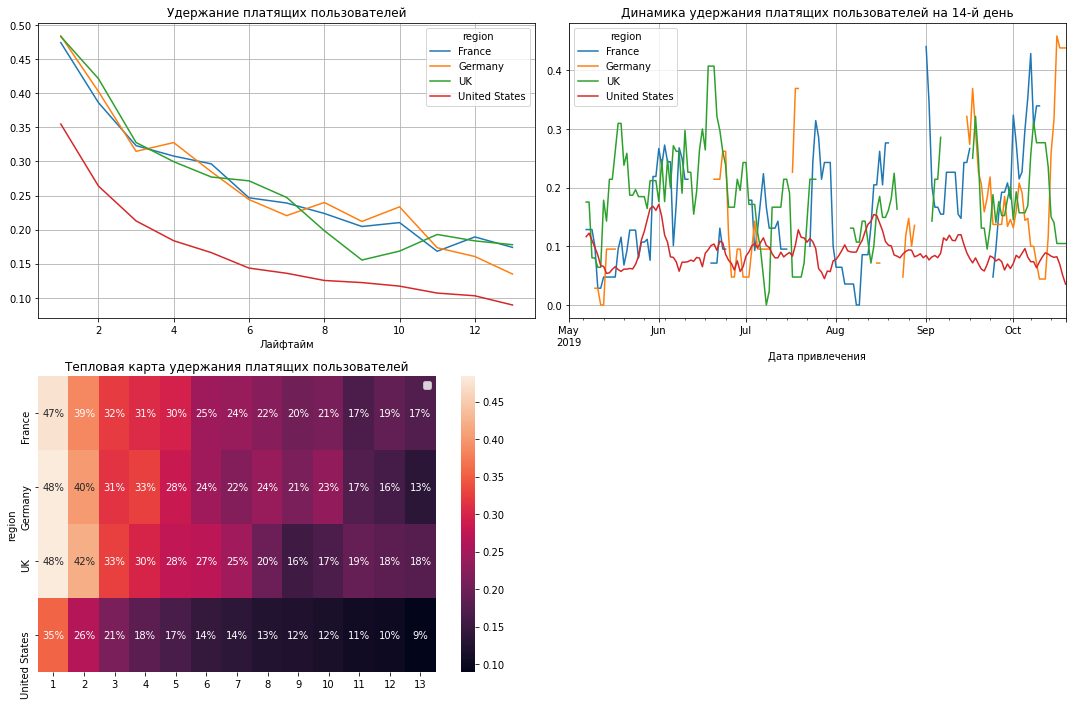

In [49]:
# удержание платящих пользователей по странам
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_new, visits, observation_date, horizon_days, dimensions=['region']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Аналогичная ситуация - в США самый низкий показатель удержания - 9%, но так же самый высокий показатель конверсии.

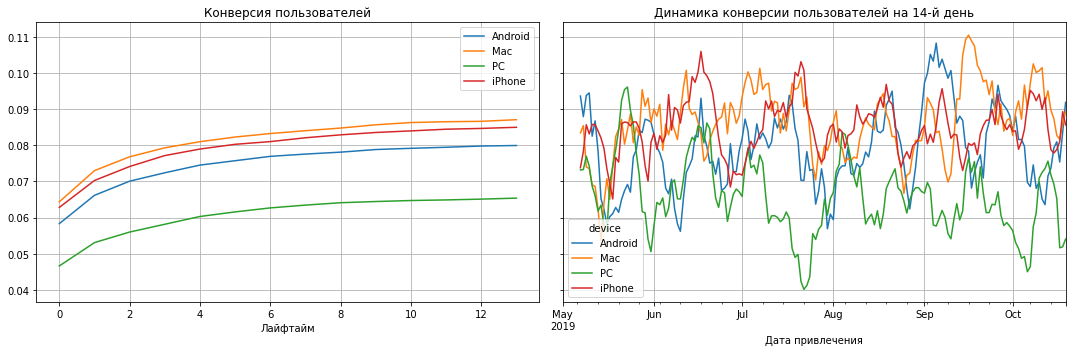

In [50]:
# конверсия пользователей по типу устройства
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_new, orders, observation_date, horizon_days, dimensions=['device']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

No handles with labels found to put in legend.


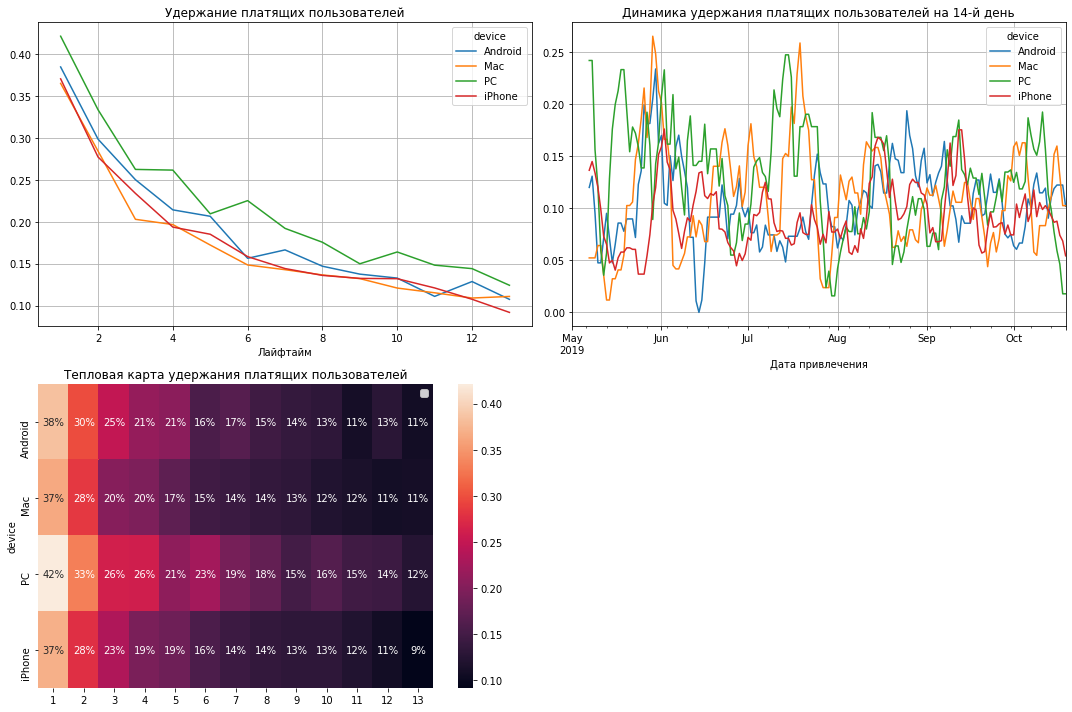

In [51]:
# удержание платящих пользователей по типу устройства
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_new, visits, observation_date, horizon_days, dimensions=['device']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

По типам устройства у всех довольно плохой показатель удержания до 12%. У типа iPhone самый низкий показатель удержания - 9%, но так же самый высокий показатель конверсии.

***Вывод:*** \
По исследуемым графикам выявлены следующие наблюдения:
- реклама не окупалась за выделенный период. ROI — около 80%;
- CAC не стабилен - сильно вырос, большой скачек в июне. Значит, дело в увеличении рекламного бюджета. Из-за этого окупаемость сильно упала;
- LTV подвержен сезонности, но стабилен;
- тогда, когда динамика конверсии растет, то падает динамика удержания;
Подтвердилось предположение, что после рекламы клиенты активно закупались, но быстро уходили.
Не оправдались расходы на привлечение пользователей из США с типом устройства iPhone,Mac и Android по каналам TipTop, FaceBoom и AdNonSense.

## Общий выводы

- Выделите причины неэффективности привлечения пользователей.
- Сформулируйте рекомендации для отдела маркетинга.

***Результат:*** \
В целях выявления причин убытков за последнии несколько месяцев были проанализированы данные о пользователях, привлечённых с 1 мая по 27 октября 2019 года. \
На этапе предобработки столбцы с датой и временем в каждом датасете переведены в формат datetime и корректно переобразовали названия столбов. \
В исследовании были данные о 4 странах: США, Великобритания, Франция и Германия, о 4 типах устройств: iPhone, Android, PC, Mac и о 10 каналах привлечения пользователей. Установлен момент и горизонт анализа, как указано в условии проекта - 1 ноября 2019 года и 14 дней соответственно. Следовательно, максимально возможная дата привлечения с учётом горизонта это 19 октября 2019 года. \
Растущие по расходам калалы: WahooNetBanner, OppleCreativeMedia, LeapBob и два канала с крайне высоими расходами - TipTop и FaceBoom. Сократили свои расходы следущие каналы привлечения: AdNonSense, RocketSuperAds, lambdaMediaAds, YRabbit и MediaTornado. 

Установили важные инсайты:
- Самое большое количество пользователей через канал organic, имеющий самую низкую долю платящих пользователей - 2%.
- Больше всего платящих пользователей и больше всего затрат на рекламу было в США с типом устройства iPhone, Android и Mac  по каналам TipTop, FaceBoom и AdNonSense - по ним же не оправдались расходы. 
- Данные параметры оказали негативное влияние на окупаемость рекламы. Реклама не окупалась за выделенный период. 
- Тогда, когда динамика конверсии растет, то падает динамика удержания. 

Подтвердилось предположение, что после рекламы клиенты активно закупались, но быстро уходили. Необходимо напоминать о себе, создавать акции для повторных покупок.

Рекомендации:
- Посмотреть на каком этапе пользователи покидают приложение по типам устройств, возможно что-то не так со страницей лендинга, или есть проблемы по техническим харакетристикам работы приложения, или проблемы со страницей оплаты. Обратить внимание на тип устройства PC - мало клиентов становится реальными покупателями.
- Изучить целевую аудиторию, рассылки подходящим пользователям.
- Изучить потребности рынка. Возможно какие-то товары просто неактуальны.
- Так же стоит не забывать про имеющихся клиентов, напоминать о себе, например, смс уведомления о скидках и акциях, для увеличения повторный покупок. Оптимизировать клиентский опыт.
- Проработать рекламу для жителей Франции, Великобритании и Германии, уж слишком маленькая конверсия в этих странах, но покупают повторно лучше.
- Так как самое большое кол-во пользователей приходит самостоятельно, необходимо их сделать покупателями - провести конкурентный анализ по товарам (возможно цены высокие) или же плохое описание товара, плохая малоинформативная реклама. Тут важно знать информацию о клиенте, чтобы выдавать на первой же странице интересующие его товары.